In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pop_tools

/global/common/software/m4632/conda/cworthy/lib/python3.11/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
from analysis import open_deficit_tracer_experiment, open_true_curve, open_deficit_tracer_curve

In [3]:
def get_colors(ids):
    cmap = plt.get_cmap("Paired")
    n = len(ids)
    return {id_: cmap(i % cmap.N) for i, id_ in enumerate(ids)}

## Experiment and polygon IDs

In [4]:
ids = ["000"]
ids = ["000", "001", "150", "151", "350", "351", "651", "655"]

In [5]:
colors = get_colors(ids)

## Polygons

In [6]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

In [7]:
def _plot_polygons(ax, suffix, mode, ids, color_map):
    ds = open_deficit_tracer_experiment(suffix=suffix, first_file=True)

    if mode == "dor":
        forcing_varname = "DELTADIC"

    elif mode == "oae":
        forcing_varname = "DELTAALK"
        
    # Initialize mask with zeros for ocean
    mask = xr.full_like(ds[f"{forcing_varname}{ids[0]}_FORCING"].isel(time=0), 0, dtype=int)
    
    # Assign each polygon a unique integer
    for i, polygon_id in enumerate(ids):
        mask += xr.where(
            ds[f"{forcing_varname}{polygon_id}_FORCING"].isel(time=0) > 0,
            i + 1,
            0
        )

    # Set land cells (KMT==0) to NaN
    mask = mask.where(ds.KMT > 0, np.nan)

    # Colors: first entry is ocean (0), then polygon colors, land (NaN) handled via set_bad
    colors = ["white"] + [color_map[i] for i in ids]
    cmap = ListedColormap(colors)
    #cmap.set_bad("gray")  # Land cells (NaN) will appear gray

    # Norm for discrete values: 0 (ocean), 1..N polygons
    bounds = np.arange(0, len(ids) + 2) - 0.5
    norm = BoundaryNorm(bounds, ncolors=len(colors))

    grid = pop_tools.get_grid("POP_gx1v7")
    
    p = ax.pcolormesh(
        grid.TLONG,
        grid.TLAT,
        mask,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree()
    )
    _add_coastlines_and_gridlines(ax)


In [8]:
def plot_polygons(suffix, mode, ids, color_map):
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})

    _plot_polygons(ax, suffix, mode, ids, color_map)
    
    # --- Add legend ---
    legend_handles = []
    for i, polygon_id in enumerate(ids):
        legend_handles.append(Patch(facecolor=color_map[polygon_id], edgecolor="black", label=f"Polygon {polygon_id}"))

    ax.legend(
        handles=legend_handles,
        loc="upper center",    
        bbox_to_anchor=(0.5, -0.1),
        ncol=4
    )
    ax.set_title("Polygons")
    return fig

In [9]:
suffix = "all-dor-daily"
mode = "dor"

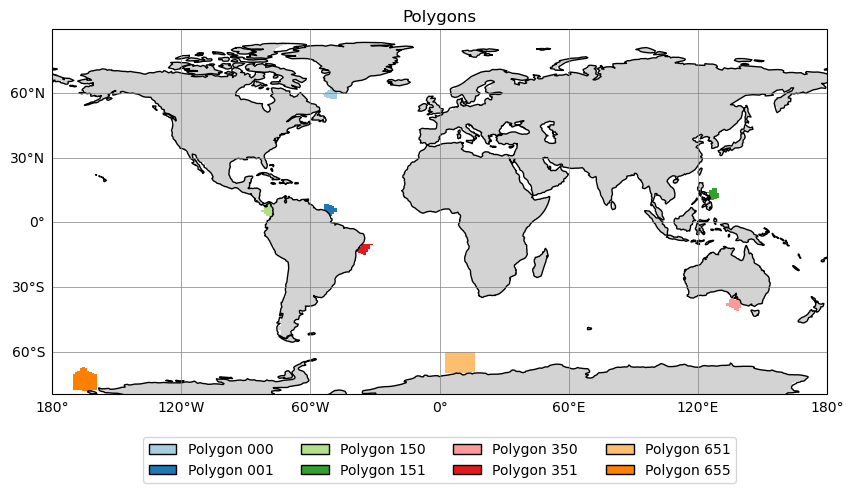

In [10]:
fig = plot_polygons(suffix, mode, ids, colors)

## Efficiency curves

Conversion factor:
$$
1 nmol = 10^{-9} mol
$$
Mass of CO₂ per mole: 44 g/mol

Mass of 1 mmol:
$$
    10^{-9} \cdot 44 g = 4.4 \cdot 10^{-8} g = 4.4 \cdot 10^{-17} kt
$$

In [11]:
factor = 4.4e-17

In [12]:
def compare_curves(polygon_ids, mode, suffix, normalized=True, colors=colors):
    """
    Compares true uptake curves against deficit tracer curves.
    Accepts a list of up to 4 polygon_id's. 
    'colors' can be a list of colors; if None, uses a standard cycle.
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Default color cycle
    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    
    for i, p_id in enumerate(polygon_ids):
        label = f"ID: {p_id}"
        # Safely pick color
        if colors is None:
            color = default_colors[i % len(default_colors)]
        elif isinstance(colors, dict):
            color = colors.get(p_id, default_colors[i % len(default_colors)])
        else:  # list-like
            color = colors[i % len(colors)]
            
        
        # Data Retrieval
        ds_true = open_true_curve(p_id, mode)
        ds_tilde = open_deficit_tracer_curve(p_id, suffix)
        
        # Calculation Logic
        if normalized:
            curve = (ds_true.uptake / ds_true.forcing).squeeze()
            curve_tilde = ds_tilde.uptake / ds_tilde.forcing
            if mode == "dor":
                curve = -1 * curve
                curve_tilde = -1 * curve_tilde
        else:
            curve = ds_true.uptake * factor
            curve_tilde = ds_tilde.uptake * factor

        # Plotting
        axs[0].plot(curve.elapsed_time / 365, curve, 
                lw=3, color="k", alpha=0.7, label="_none")
        
        axs[0].plot(curve_tilde.elapsed_time / 365, curve_tilde, 
                lw=2, color=color,
                label=label)

        # Find the minimum length
        min_len = min(len(curve), len(curve_tilde))
        # Truncate arrays
        x = curve.elapsed_time[:min_len] / 365
        y = curve_tilde[:min_len].values - curve[:min_len].values

        # Plot
        axs[1].plot(x, y, lw=2, color=color, label=label)

    if normalized:
        title = "Uptake efficiency"   
        axs[0].set_ylim([0, 1.1])  
    else:
        title = r"Total CO$_2$ uptake" 
        axs[0].set_ylabel(r"[ktCO$_2$]")
        axs[1].set_ylabel(r"[ktCO$_2$]")
    # Styling
    # axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    for ax in axs:
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="white")
        ax.set_xlabel("Years")
        ax.set_facecolor("#f0f0f0") 
    
    axs[0].set_title(title)
    axs[1].set_title("Difference in uptake efficiencies: CDR Tracer - Truth")

    fig.suptitle(mode.upper())
    plt.tight_layout()
    return fig

In [13]:
suffix = "all-oae-daily"
mode = "oae"

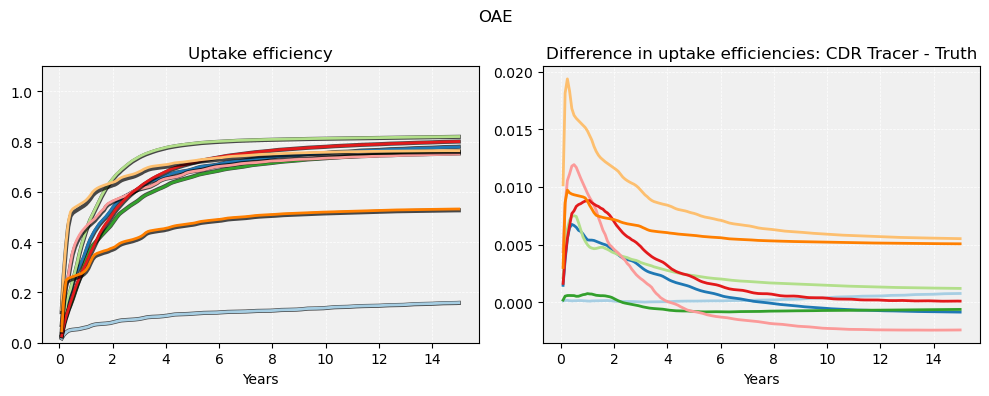

In [14]:
fig = compare_curves(ids, mode, suffix, normalized=True)

In [15]:
suffix = "all-dor-daily"
mode = "dor"

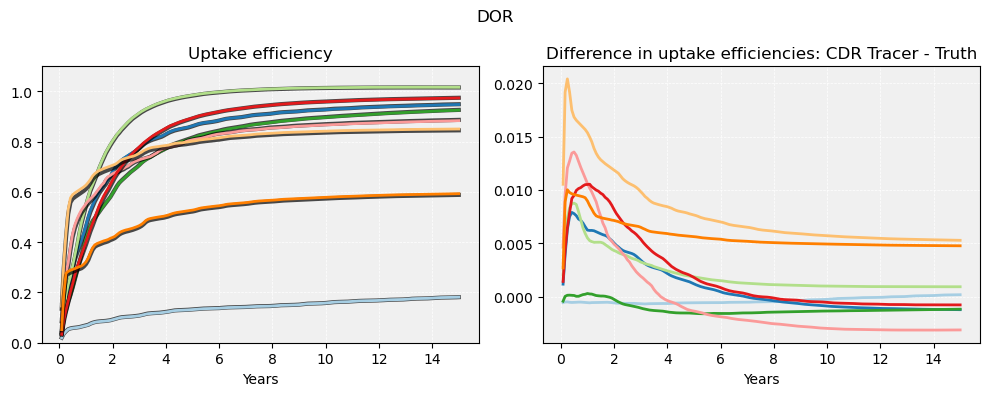

In [16]:
fig = compare_curves(ids, mode, suffix, normalized=True)

## Air-sea flux

In [17]:
def compare_air_sea_flux(p_id, mode, suffix):

    # Data Retrieval
    ds_true = open_true_curve(p_id, mode)
    ds_tilde = open_deficit_tracer_curve(p_id, suffix)    

    curve = (ds_true.uptake).squeeze()
    curve_tilde = ds_tilde.uptake
    
    fig, ax = plt.subplots()
    
    ax.plot(curve.elapsed_time, curve, label="CESM-MARBL", lw=2)
    ax.plot(curve_tilde.elapsed_time, curve_tilde, label="CESM", lw=2)

    ax.legend()
    ax.grid()

    ax.set_title(f"Polygon ID: {p_id}")
    ax.set_xlabel("Days")
    
    title = "Air-sea flux"
        
    ax.set_ylabel(title)
    
    return fig

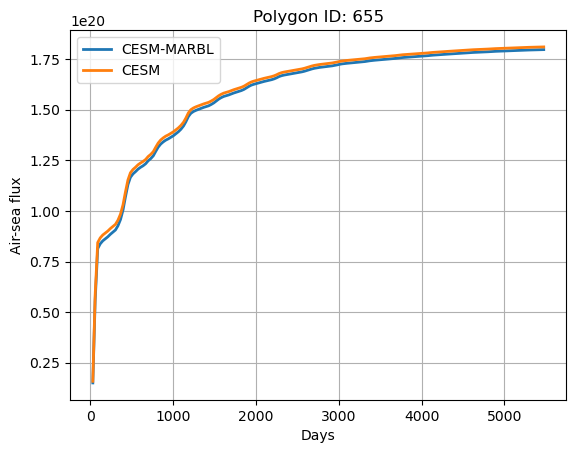

In [18]:
fig = compare_air_sea_flux("655", "dor", "all-dor-daily")

## Forcing

In [19]:
def compare_forcing(p_id, mode, suffix):

    # Data Retrieval
    ds_true = open_true_curve(p_id, mode)
    ds_tilde = open_deficit_tracer_curve(p_id, suffix)    

    curve = (ds_true.forcing).squeeze()
    curve_tilde = ds_tilde.forcing
    
    fig, ax = plt.subplots()
    
    ax.plot(curve.elapsed_time, curve, label="CESM-MARBL", lw=2)
    ax.plot(curve_tilde.elapsed_time, curve_tilde, label="CESM", lw=2)

    ax.legend()
    ax.grid()

    ax.set_title(f"Polygon ID: {p_id}")
    ax.set_xlabel("Days")
    
    title = "Air-sea flux"
        
    ax.set_ylabel(title)
    
    return fig

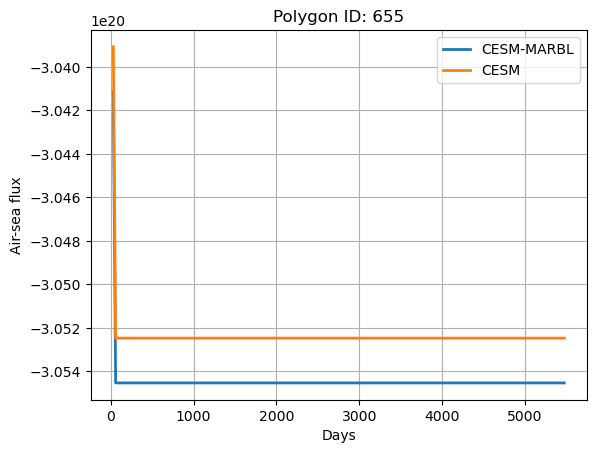

In [20]:
fig = compare_forcing("655", "dor", "all-dor-daily")